# Multimodal Temporal Divergence Analysis

**Purpose**: Unified analysis of WHEN physiological, gaze, and EEG signals diverge between INVEST vs KEEP decisions within the PRE-decision window.

**Key Questions**:
1. When does each modality's signal emerge relative to decision submission?
2. Do EEG frequency bands show different temporal profiles than pupil/gaze?
3. Can time-aligned feature extraction improve classification?

**Modalities Analyzed**:
- **Pupil**: Pupil size and dynamics (baselined)
- **Gaze**: Eye movement patterns and fixations
- **EEG**: Band power across brain regions (Delta, Theta, Alpha, Beta)

**Method**:
1. Divide PRE-decision window into sub-windows (500ms bins)
2. Extract features within each sub-window for all modalities
3. Test for significant divergence at each time point
4. Visualize cross-modality temporal evolution

In [1]:
import sys
sys.path.append('../..')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats, signal
from tqdm import tqdm
from datetime import datetime
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Import project utilities
from src.models.fusion import weighted_late_fusion
from src.features.eeg_features import FREQ_BANDS, CHANNEL_REGIONS, CHANNEL_NAMES

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print(f"\n{'='*80}")
print(f"MULTIMODAL TEMPORAL DIVERGENCE ANALYSIS")
print(f"{'='*80}\n")
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


MULTIMODAL TEMPORAL DIVERGENCE ANALYSIS

Analysis started: 2026-03-29 20:07:28


## 1. Configuration

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Time window settings (PRE-decision)
WINDOW_START = -2.0  # seconds before submit
WINDOW_END = 0.0     # at submit
BIN_SIZE = 0.5       # 500ms bins

# Generate time bins
TIME_BINS = []
t = WINDOW_START
while t < WINDOW_END:
    TIME_BINS.append((t, min(t + BIN_SIZE, WINDOW_END)))
    t += BIN_SIZE

BIN_LABELS = [f"{tb[0]:.1f}s to {tb[1]:.1f}s" for tb in TIME_BINS]

print(f"Analysis window: {WINDOW_START}s to {WINDOW_END}s")
print(f"Bin size: {BIN_SIZE}s")
print(f"Time bins: {TIME_BINS}")

# Paths
PREPROCESSING_DIR = Path('../../data/results/preprocessing')
RAW_DIR = Path('../../data/raw/json')
EEG_DATA_PATH = Path('../../data/eeg/Copy of preprocessed_eeg.pkl')
OUTPUT_DIR = Path('../../data/results/main/statistical_analyses/multimodal_temporal')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_METHOD = 't3_stable_pre_decision'

# EEG settings
EEG_FS = 256  # Sampling rate
EEG_DURATION = 1.25  # seconds (320 samples)

Analysis window: -2.0s to 0.0s
Bin size: 0.5s
Time bins: [(-2.0, -1.5), (-1.5, -1.0), (-1.0, -0.5), (-0.5, 0.0)]


## 2. Load Data and Outcomes

In [3]:
# Load outcomes from extracted features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

outcomes_df = feature_data['merged_df'][['subject_id', 'trial_id', 'outcome']].copy()
outcome_lookup = dict(zip(outcomes_df['trial_id'], outcomes_df['outcome']))
print(f"Loaded outcomes for {len(outcome_lookup)} trials")

# Load EEG data
print(f"\nLoading EEG data from: {EEG_DATA_PATH}")
with open(EEG_DATA_PATH, 'rb') as f:
    eeg_df = pickle.load(f)

print(f"Loaded {len(eeg_df)} EEG trials")
print(f"EEG subjects: {eeg_df['subject_date_id'].nunique()}")
print(f"EEG array shape: {eeg_df['display_eeg'].iloc[0].shape} (time x channels)")

# Create EEG lookup: trial_id -> eeg_data
# EEG trial_id is 0-indexed integer, preprocessing trial_id is 1-indexed string
eeg_lookup = {}
for _, row in eeg_df.iterrows():
    # Store with 0-indexed key (as in EEG data)
    trial_key = f"{row['trial_id']}_{row['subject_date_id']}"
    eeg_lookup[trial_key] = row['display_eeg']

print(f"Created EEG lookup for {len(eeg_lookup)} trials")

# Show sample keys for debugging
sample_keys = list(eeg_lookup.keys())[:5]
print(f"Sample EEG keys: {sample_keys}")

Loaded outcomes for 12107 trials

Loading EEG data from: ../../data/eeg/Copy of preprocessed_eeg.pkl
Loaded 10855 EEG trials
EEG subjects: 85
EEG array shape: (320, 20) (time x channels)
Created EEG lookup for 10855 trials
Sample EEG keys: ['0_0831_1300_9M4VCHG', '1_0831_1300_9M4VCHG', '2_0831_1300_9M4VCHG', '3_0831_1300_9M4VCHG', '4_0831_1300_9M4VCHG']


## 3. Feature Extraction Functions

In [4]:
def extract_pupil_features_for_bin(pupil_data, time_data, time_bin):
    """
    Extract pupil features for a specific time bin.
    """
    mask = (time_data >= time_bin[0]) & (time_data < time_bin[1])
    pupil = pupil_data[mask]
    time_filtered = time_data[mask]
    
    if len(pupil) < 3:
        return None
    
    pupil_velocity = np.diff(pupil) if len(pupil) > 1 else np.array([0])
    pupil_acceleration = np.diff(pupil_velocity) if len(pupil_velocity) > 1 else np.array([0])
    dilation_mask = pupil_velocity > 0 if len(pupil_velocity) > 0 else np.array([False])
    
    features = {
        'pupil_mean': np.mean(pupil),
        'pupil_median': np.median(pupil),
        'pupil_std': np.std(pupil),
        'pupil_range': np.max(pupil) - np.min(pupil),
        'pupil_cv': np.std(pupil) / np.abs(np.mean(pupil)) if np.mean(pupil) != 0 else 0,
        'pupil_slope': np.polyfit(time_filtered, pupil, 1)[0] if len(time_filtered) > 1 else 0,
        'pupil_velocity_mean': np.mean(np.abs(pupil_velocity)) if len(pupil_velocity) > 0 else 0,
        'pupil_velocity_std': np.std(pupil_velocity) if len(pupil_velocity) > 0 else 0,
        'pupil_max_dilation_rate': np.max(pupil_velocity) if len(pupil_velocity) > 0 else 0,
        'pupil_max_constriction_rate': np.abs(np.min(pupil_velocity)) if len(pupil_velocity) > 0 else 0,
        'pupil_acceleration_mean': np.mean(np.abs(pupil_acceleration)) if len(pupil_acceleration) > 0 else 0,
        'pct_time_dilating': np.mean(dilation_mask) if len(dilation_mask) > 0 else 0,
        'pupil_min': np.min(pupil),
        'pupil_max': np.max(pupil),
    }
    
    return features


def extract_eeg_features_for_bin(eeg_data, bin_idx, n_bins=4, fs=256):
    """
    Extract EEG band power features for a specific time bin.
    
    EEG data is 1.25s (320 samples). We divide into bins matching pupil analysis.
    Since EEG window is shorter than pupil window, we map bins proportionally.
    
    Parameters
    ----------
    eeg_data : np.ndarray
        EEG data with shape (n_samples, n_channels) = (320, 20)
    bin_idx : int
        Which time bin (0-3 for 4 bins)
    n_bins : int
        Total number of bins
    fs : int
        Sampling frequency
    
    Returns
    -------
    dict or None
        Dictionary of EEG features
    """
    n_samples = eeg_data.shape[0]  # 320
    samples_per_bin = n_samples // n_bins  # 80 samples per bin (~312ms)
    
    start_sample = bin_idx * samples_per_bin
    end_sample = start_sample + samples_per_bin
    
    # Extract bin data and transpose to (channels, samples)
    bin_data = eeg_data[start_sample:end_sample, :].T  # (20 channels, 80 samples)
    
    if bin_data.shape[1] < 32:  # Need minimum samples for PSD
        return None
    
    features = {}
    
    # Compute PSD using Welch's method
    try:
        freqs, psd = signal.welch(bin_data, fs=fs, nperseg=min(64, bin_data.shape[1]))
    except:
        return None
    
    # Extract band power for each frequency band and region
    for band_name, (f_low, f_high) in FREQ_BANDS.items():
        freq_mask = (freqs >= f_low) & (freqs <= f_high)
        
        if freq_mask.sum() == 0:
            continue
        
        # Band power per channel
        try:
            band_power = np.trapz(psd[:, freq_mask], freqs[freq_mask], axis=1)
        except:
            band_power = np.trapezoid(psd[:, freq_mask], freqs[freq_mask], axis=1)
        
        # Regional averages
        for region, channels in CHANNEL_REGIONS.items():
            ch_indices = [CHANNEL_NAMES.index(ch) for ch in channels if ch in CHANNEL_NAMES]
            if len(ch_indices) > 0:
                avg_power = np.mean(band_power[ch_indices])
                features[f'eeg_{band_name}_{region}'] = avg_power
    
    return features if len(features) > 0 else None


print("Feature extraction functions defined")
print(f"\nEEG frequency bands: {FREQ_BANDS}")
print(f"EEG regions: {list(CHANNEL_REGIONS.keys())}")

Feature extraction functions defined

EEG frequency bands: {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}
EEG regions: ['Frontal', 'Central', 'Parietal', 'Occipital']


## 4. Extract Temporal Features for All Modalities

In [5]:
# Load preprocessing files
preprocessing_files = sorted(PREPROCESSING_DIR.glob('preprocessing_*.json'))
print(f"Found {len(preprocessing_files)} preprocessing files")

# Storage for all trials
all_trials_data = []
eeg_matched_count = 0

for preprocessed_file in tqdm(preprocessing_files, desc="Processing subjects"):
    with open(preprocessed_file, 'r') as f:
        preprocessed = json.load(f)
    
    subject_id = preprocessed['subject_id']
    
    for trial_id, trial_data in preprocessed['trial_data'].items():
        method_data = trial_data['methods'][BASELINE_METHOD]
        
        if method_data['success'] != True:
            continue
        
        # Get outcome from lookup
        lookup_key = f"{trial_id}_{subject_id}"
        if lookup_key not in outcome_lookup:
            continue
        
        outcome = outcome_lookup[lookup_key]
        
        # Extract pupil data
        time_aligned = np.array(trial_data['time_relative_to_submit'])
        pupil_avg = np.array(method_data['pupil_avg_baselined'])
        pupil_L = np.array(method_data['pupil_L_baselined'])
        pupil_R = np.array(method_data['pupil_R_baselined'])
        
        # Clean NaN values
        valid_mask = ~np.isnan(pupil_avg)
        pupil_avg_clean = pupil_avg[valid_mask]
        pupil_L_clean = pupil_L[valid_mask]
        pupil_R_clean = pupil_R[valid_mask]
        time_clean = time_aligned[valid_mask]
        
        if len(pupil_avg_clean) < 20:
            continue
        
        # Check if EEG data available
        # EEG trial_id format: "trial_subjectid" where trial is 0-indexed
        eeg_trial_key = f"{int(trial_id)-1}_{subject_id}"  # Convert to 0-indexed
        has_eeg = eeg_trial_key in eeg_lookup
        
        trial_row = {
            'subject_id': subject_id,
            'trial_id': trial_id,
            'outcome': outcome,
            'has_eeg': has_eeg
        }
        
        # Extract pupil features for each time bin
        valid_pupil_bins = 0
        for bin_idx, time_bin in enumerate(TIME_BINS):
            bin_features = extract_pupil_features_for_bin(pupil_avg_clean, time_clean, time_bin)
            
            if bin_features is not None:
                valid_pupil_bins += 1
                for feat_name, feat_val in bin_features.items():
                    trial_row[f'{feat_name}_bin{bin_idx}'] = feat_val
            
            # Eye asymmetry
            bin_mask = (time_clean >= time_bin[0]) & (time_clean < time_bin[1])
            L_bin = pupil_L_clean[bin_mask]
            R_bin = pupil_R_clean[bin_mask]
            if len(L_bin) > 0:
                trial_row[f'eye_asymmetry_bin{bin_idx}'] = np.nanmean(np.abs(L_bin - R_bin))
        
        # Extract EEG features for each time bin (if available)
        if has_eeg:
            eeg_data = eeg_lookup[eeg_trial_key]
            valid_eeg_bins = 0
            
            for bin_idx in range(len(TIME_BINS)):
                eeg_features = extract_eeg_features_for_bin(eeg_data, bin_idx, n_bins=len(TIME_BINS))
                
                if eeg_features is not None:
                    valid_eeg_bins += 1
                    for feat_name, feat_val in eeg_features.items():
                        trial_row[f'{feat_name}_bin{bin_idx}'] = feat_val
            
            if valid_eeg_bins == len(TIME_BINS):
                eeg_matched_count += 1
        
        if valid_pupil_bins == len(TIME_BINS):
            all_trials_data.append(trial_row)

# Create DataFrame
df = pd.DataFrame(all_trials_data)
print(f"\nTotal trials with complete pupil bins: {len(df)}")
print(f"Trials with EEG data: {df['has_eeg'].sum()}")
print(f"Subjects: {df['subject_id'].nunique()}")
print(f"\nOutcome distribution:")
print(df['outcome'].value_counts())

Found 105 preprocessing files


Processing subjects: 100%|██████████| 105/105 [01:30<00:00,  1.16it/s]



Total trials with complete pupil bins: 10048
Trials with EEG data: 8160
Subjects: 102

Outcome distribution:
outcome
1    6296
0    3752
Name: count, dtype: int64


## 5. Compute Temporal Divergence Statistics

In [6]:
def compute_cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std


# Define feature lists
PUPIL_FEATURES = [
    'pupil_mean', 'pupil_median', 'pupil_std', 'pupil_range', 'pupil_cv',
    'pupil_slope', 'pupil_velocity_mean', 'pupil_velocity_std',
    'pupil_max_dilation_rate', 'pupil_max_constriction_rate',
    'pupil_acceleration_mean', 'pct_time_dilating', 'pupil_min', 'pupil_max',
    'eye_asymmetry',
]

EEG_FEATURES = []
for band in FREQ_BANDS.keys():
    for region in CHANNEL_REGIONS.keys():
        EEG_FEATURES.append(f'eeg_{band}_{region}')

print(f"Pupil features: {len(PUPIL_FEATURES)}")
print(f"EEG features: {len(EEG_FEATURES)}")

# Separate by outcome
invest_trials = df[df['outcome'] == 1]
keep_trials = df[df['outcome'] == 0]

# For EEG, use only trials with EEG data
eeg_df = df[df['has_eeg'] == True]
invest_eeg = eeg_df[eeg_df['outcome'] == 1]
keep_eeg = eeg_df[eeg_df['outcome'] == 0]

print(f"\nINVEST trials (pupil): {len(invest_trials)}")
print(f"KEEP trials (pupil): {len(keep_trials)}")
print(f"INVEST trials (EEG): {len(invest_eeg)}")
print(f"KEEP trials (EEG): {len(keep_eeg)}")

Pupil features: 15
EEG features: 16

INVEST trials (pupil): 6296
KEEP trials (pupil): 3752
INVEST trials (EEG): 5114
KEEP trials (EEG): 3046


In [7]:
# Compute statistics for PUPIL features
temporal_results = []

for feature in PUPIL_FEATURES:
    for bin_idx, time_bin in enumerate(TIME_BINS):
        col_name = f'{feature}_bin{bin_idx}'
        
        if col_name not in df.columns:
            continue
        
        invest_vals = invest_trials[col_name].dropna()
        keep_vals = keep_trials[col_name].dropna()
        
        if len(invest_vals) < 10 or len(keep_vals) < 10:
            continue
        
        t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
        cohens_d = compute_cohens_d(invest_vals, keep_vals)
        
        temporal_results.append({
            'modality': 'pupil',
            'feature': feature,
            'bin_idx': bin_idx,
            'time_label': BIN_LABELS[bin_idx],
            'invest_mean': invest_vals.mean(),
            'keep_mean': keep_vals.mean(),
            't_statistic': t_stat,
            'p_value': p_val,
            'cohens_d': cohens_d,
            'abs_cohens_d': abs(cohens_d),
            'significant': p_val < 0.05,
        })

# Compute statistics for EEG features
for feature in EEG_FEATURES:
    for bin_idx, time_bin in enumerate(TIME_BINS):
        col_name = f'{feature}_bin{bin_idx}'
        
        if col_name not in eeg_df.columns:
            continue
        
        invest_vals = invest_eeg[col_name].dropna()
        keep_vals = keep_eeg[col_name].dropna()
        
        if len(invest_vals) < 10 or len(keep_vals) < 10:
            continue
        
        t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
        cohens_d = compute_cohens_d(invest_vals, keep_vals)
        
        temporal_results.append({
            'modality': 'eeg',
            'feature': feature,
            'bin_idx': bin_idx,
            'time_label': BIN_LABELS[bin_idx],
            'invest_mean': invest_vals.mean(),
            'keep_mean': keep_vals.mean(),
            't_statistic': t_stat,
            'p_value': p_val,
            'cohens_d': cohens_d,
            'abs_cohens_d': abs(cohens_d),
            'significant': p_val < 0.05,
        })

temporal_df = pd.DataFrame(temporal_results)

# Add Bonferroni correction
n_tests = len(temporal_df)
temporal_df['significant_bonferroni'] = temporal_df['p_value'] < (0.05 / n_tests)

print(f"Computed {len(temporal_df)} feature-bin combinations")
print(f"  Pupil: {len(temporal_df[temporal_df['modality'] == 'pupil'])}")
print(f"  EEG: {len(temporal_df[temporal_df['modality'] == 'eeg'])}")

Computed 124 feature-bin combinations
  Pupil: 60
  EEG: 64


In [8]:
# Show strongest effects by modality and time bin
print("\n" + "="*90)
print("STRONGEST EFFECTS BY MODALITY AND TIME BIN")
print("="*90)

for modality in ['pupil', 'eeg']:
    print(f"\n{'='*40}")
    print(f"  {modality.upper()} FEATURES")
    print(f"{'='*40}")
    
    mod_df = temporal_df[temporal_df['modality'] == modality]
    
    for bin_idx, time_bin in enumerate(TIME_BINS):
        bin_data = mod_df[mod_df['bin_idx'] == bin_idx].sort_values('abs_cohens_d', ascending=False)
        print(f"\n--- Time Bin {bin_idx}: {BIN_LABELS[bin_idx]} ---")
        print(bin_data[['feature', 'cohens_d', 'p_value', 'significant']].head(5).to_string(index=False))


STRONGEST EFFECTS BY MODALITY AND TIME BIN

  PUPIL FEATURES

--- Time Bin 0: -2.0s to -1.5s ---
     feature  cohens_d      p_value  significant
  pupil_mean  0.143552 3.605190e-12         True
pupil_median  0.142362 5.411085e-12         True
   pupil_min  0.131695 1.784313e-10         True
   pupil_max  0.125890 1.072612e-09         True
    pupil_cv -0.051552 1.244882e-02         True

--- Time Bin 1: -1.5s to -1.0s ---
                    feature  cohens_d      p_value  significant
          pct_time_dilating -0.120088 5.969042e-09         True
                pupil_slope -0.118061 1.067870e-08         True
                  pupil_max  0.116991 1.446213e-08         True
pupil_max_constriction_rate  0.113801 3.517072e-08         True
                 pupil_mean  0.109075 1.257730e-07         True

--- Time Bin 2: -1.0s to -0.5s ---
          feature  cohens_d  p_value  significant
pct_time_dilating -0.088377 0.000018         True
        pupil_max -0.085179 0.000037         True
  

## 6. Visualize Temporal Evolution by Modality

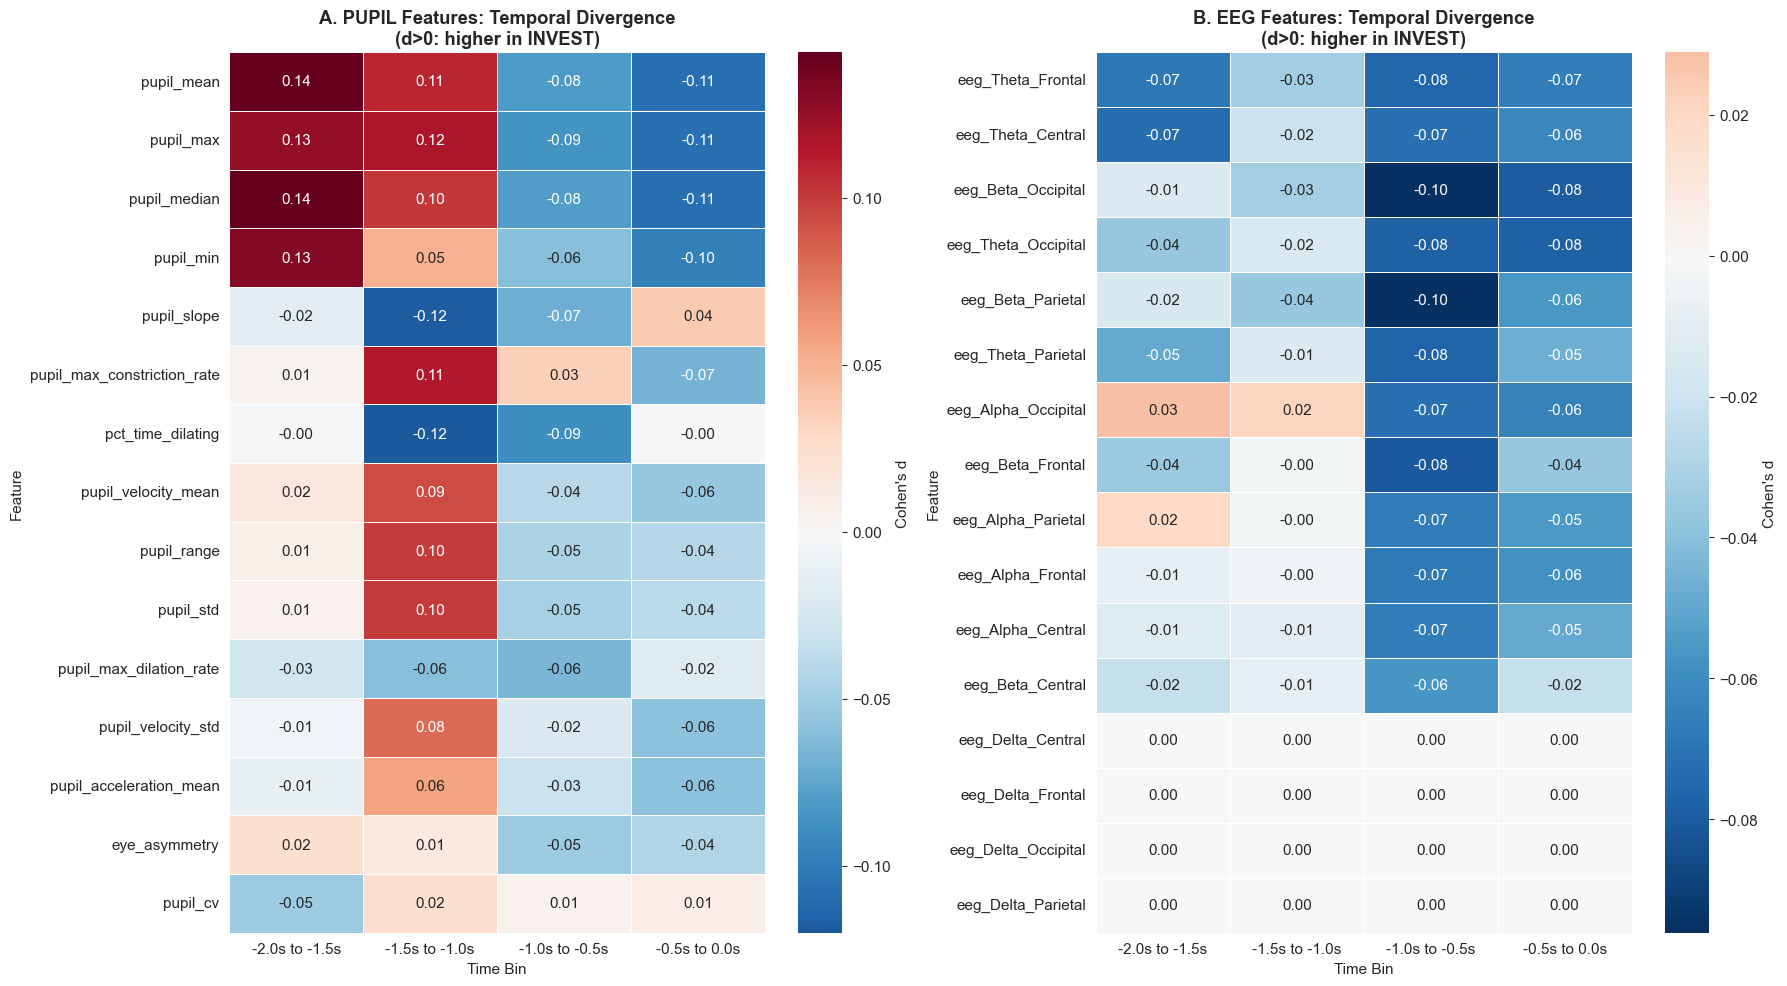

In [9]:
# Create heatmaps for pupil and EEG
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Pupil heatmap
ax1 = axes[0]
pupil_df = temporal_df[temporal_df['modality'] == 'pupil']
pivot_pupil = pupil_df.pivot(index='feature', columns='bin_idx', values='cohens_d')
pivot_pupil.columns = BIN_LABELS

# Sort by average effect
pivot_pupil['avg_abs'] = pivot_pupil.abs().mean(axis=1)
pivot_pupil = pivot_pupil.sort_values('avg_abs', ascending=False).drop('avg_abs', axis=1)

sns.heatmap(pivot_pupil, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            cbar_kws={'label': "Cohen's d"}, ax=ax1, linewidths=0.5)
ax1.set_xlabel('Time Bin')
ax1.set_ylabel('Feature')
ax1.set_title('A. PUPIL Features: Temporal Divergence\n(d>0: higher in INVEST)', fontweight='bold')

# EEG heatmap
ax2 = axes[1]
eeg_temporal = temporal_df[temporal_df['modality'] == 'eeg']

if len(eeg_temporal) > 0:
    pivot_eeg = eeg_temporal.pivot(index='feature', columns='bin_idx', values='cohens_d')
    pivot_eeg.columns = BIN_LABELS
    
    pivot_eeg['avg_abs'] = pivot_eeg.abs().mean(axis=1)
    pivot_eeg = pivot_eeg.sort_values('avg_abs', ascending=False).drop('avg_abs', axis=1)
    
    sns.heatmap(pivot_eeg, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
                cbar_kws={'label': "Cohen's d"}, ax=ax2, linewidths=0.5)
    ax2.set_xlabel('Time Bin')
    ax2.set_ylabel('Feature')
    ax2.set_title('B. EEG Features: Temporal Divergence\n(d>0: higher in INVEST)', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No EEG data available', ha='center', va='center', fontsize=14)
    ax2.set_title('B. EEG Features: No Data')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'temporal_heatmaps_by_modality.png', dpi=300, bbox_inches='tight')
plt.show()

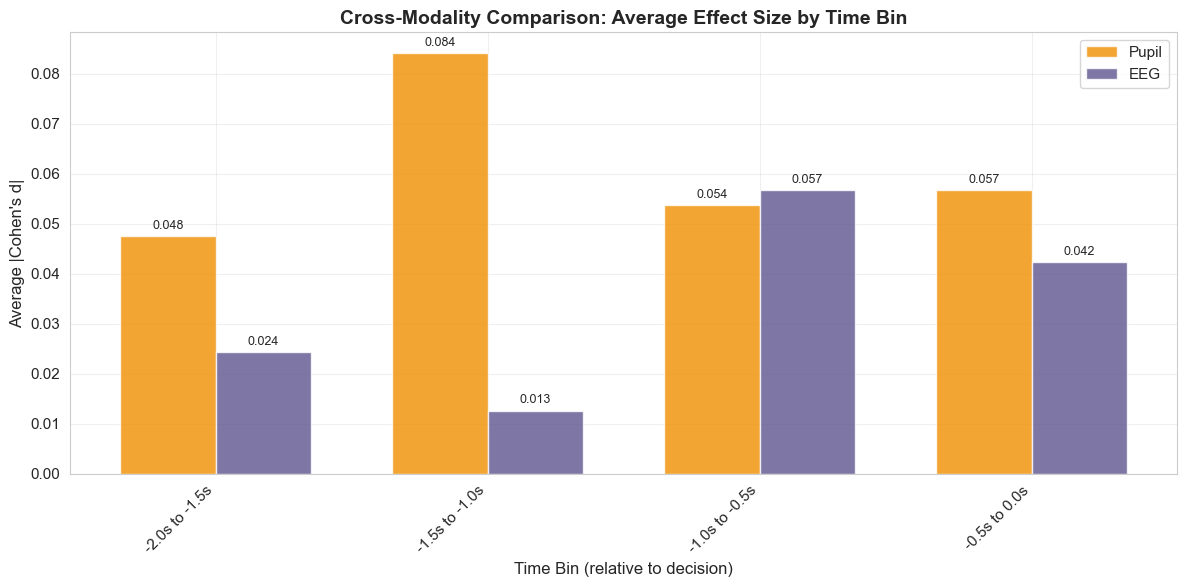

In [10]:
# Compare average effect sizes across modalities over time
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(TIME_BINS))
width = 0.35

# Average absolute effect size per modality per bin
pupil_effects = []
eeg_effects = []

for bin_idx in range(len(TIME_BINS)):
    pupil_bin = temporal_df[(temporal_df['modality'] == 'pupil') & (temporal_df['bin_idx'] == bin_idx)]
    eeg_bin = temporal_df[(temporal_df['modality'] == 'eeg') & (temporal_df['bin_idx'] == bin_idx)]
    
    pupil_effects.append(pupil_bin['abs_cohens_d'].mean() if len(pupil_bin) > 0 else 0)
    eeg_effects.append(eeg_bin['abs_cohens_d'].mean() if len(eeg_bin) > 0 else 0)

bars1 = ax.bar(x - width/2, pupil_effects, width, label='Pupil', color='#F18F01', alpha=0.8)
bars2 = ax.bar(x + width/2, eeg_effects, width, label='EEG', color='#5E548E', alpha=0.8)

ax.set_xlabel('Time Bin (relative to decision)', fontsize=12)
ax.set_ylabel('Average |Cohen\'s d|', fontsize=12)
ax.set_title('Cross-Modality Comparison: Average Effect Size by Time Bin', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(BIN_LABELS, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# Add values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_modality_effect_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. EEG Frequency Band Analysis


EEG EFFECTS BY FREQUENCY BAND (average Cohen's d across regions)
       -2.0s to -1.5s  -1.5s to -1.0s  -1.0s to -0.5s  -0.5s to 0.0s
band                                                                
Alpha        0.006448        0.001241       -0.068432      -0.056748
Beta        -0.022179       -0.020083       -0.082309      -0.048796
Delta        0.000000        0.000000        0.000000       0.000000
Theta       -0.057365       -0.020896       -0.076098      -0.063615


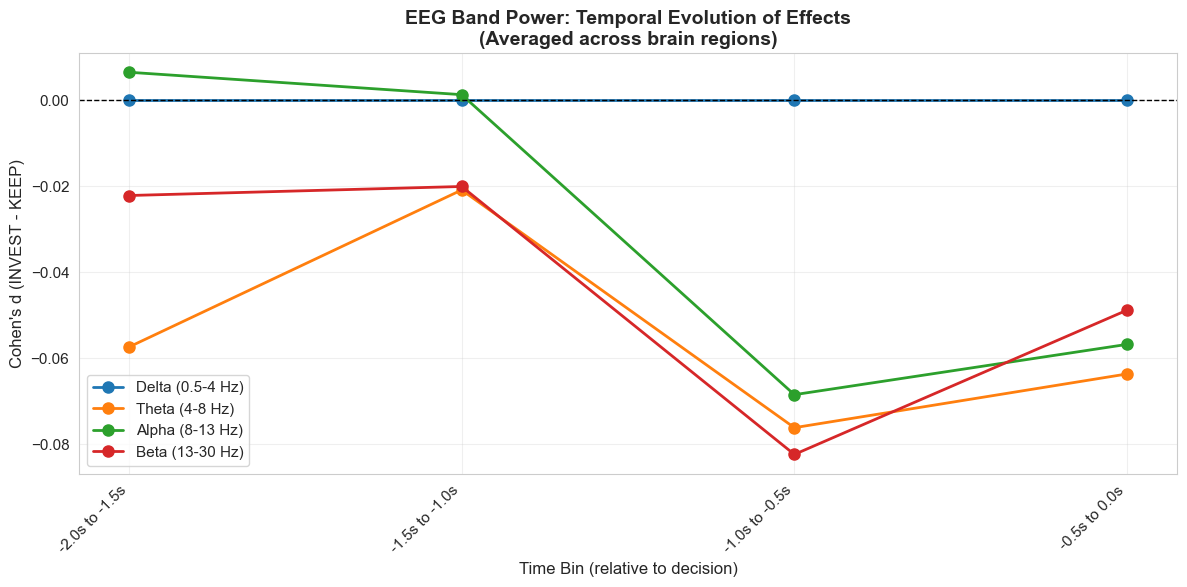

In [11]:
# Analyze EEG effects by frequency band
eeg_temporal = temporal_df[temporal_df['modality'] == 'eeg'].copy()

if len(eeg_temporal) > 0:
    # Extract band from feature name
    eeg_temporal['band'] = eeg_temporal['feature'].apply(lambda x: x.split('_')[1])
    eeg_temporal['region'] = eeg_temporal['feature'].apply(lambda x: x.split('_')[2])
    
    # Average effect by band across time
    band_effects = eeg_temporal.groupby(['band', 'bin_idx'])['cohens_d'].mean().unstack()
    band_effects.columns = BIN_LABELS
    
    print("\n" + "="*80)
    print("EEG EFFECTS BY FREQUENCY BAND (average Cohen's d across regions)")
    print("="*80)
    print(band_effects.to_string())
    
    # Plot by frequency band
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = {'Delta': '#1f77b4', 'Theta': '#ff7f0e', 'Alpha': '#2ca02c', 'Beta': '#d62728'}
    
    for band in FREQ_BANDS.keys():
        if band in band_effects.index:
            ax.plot(range(len(BIN_LABELS)), band_effects.loc[band].values, 
                    marker='o', linewidth=2, markersize=8,
                    label=f'{band} ({FREQ_BANDS[band][0]}-{FREQ_BANDS[band][1]} Hz)',
                    color=colors.get(band, 'gray'))
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, rotation=45, ha='right')
    ax.set_xlabel('Time Bin (relative to decision)', fontsize=12)
    ax.set_ylabel("Cohen's d (INVEST - KEEP)", fontsize=12)
    ax.set_title('EEG Band Power: Temporal Evolution of Effects\n(Averaged across brain regions)', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eeg_band_temporal_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No EEG temporal data available for band analysis")


EEG EFFECTS BY BRAIN REGION (average Cohen's d across bands)
           -2.0s to -1.5s  -1.5s to -1.0s  -1.0s to -0.5s  -0.5s to 0.0s
region                                                                  
Central         -0.027309       -0.009913       -0.048893      -0.033851
Frontal         -0.028409       -0.010007       -0.056215      -0.040063
Occipital       -0.005587       -0.006611       -0.061646      -0.055735
Parietal        -0.011791       -0.013208       -0.060086      -0.039510


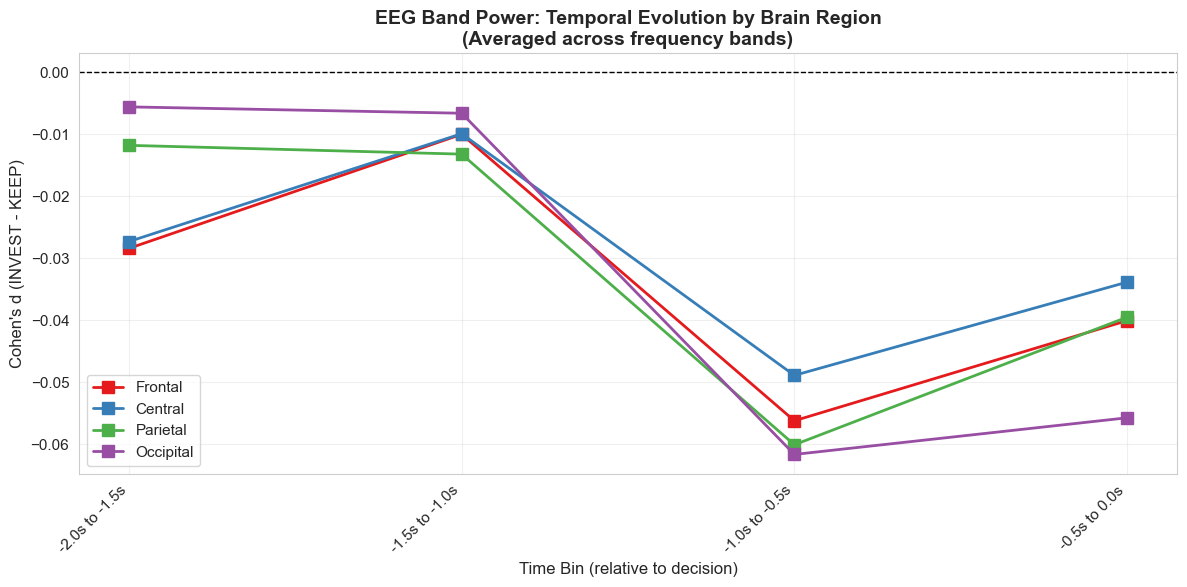

In [12]:
# Analyze EEG effects by brain region
if len(eeg_temporal) > 0:
    # Average effect by region across time
    region_effects = eeg_temporal.groupby(['region', 'bin_idx'])['cohens_d'].mean().unstack()
    region_effects.columns = BIN_LABELS
    
    print("\n" + "="*80)
    print("EEG EFFECTS BY BRAIN REGION (average Cohen's d across bands)")
    print("="*80)
    print(region_effects.to_string())
    
    # Plot by region
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = {'Frontal': '#e41a1c', 'Central': '#377eb8', 'Parietal': '#4daf4a', 'Occipital': '#984ea3'}
    
    for region in CHANNEL_REGIONS.keys():
        if region in region_effects.index:
            ax.plot(range(len(BIN_LABELS)), region_effects.loc[region].values, 
                    marker='s', linewidth=2, markersize=8,
                    label=region, color=colors.get(region, 'gray'))
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, rotation=45, ha='right')
    ax.set_xlabel('Time Bin (relative to decision)', fontsize=12)
    ax.set_ylabel("Cohen's d (INVEST - KEEP)", fontsize=12)
    ax.set_title('EEG Band Power: Temporal Evolution by Brain Region\n(Averaged across frequency bands)', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eeg_region_temporal_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Unified Cross-Modality Timeline

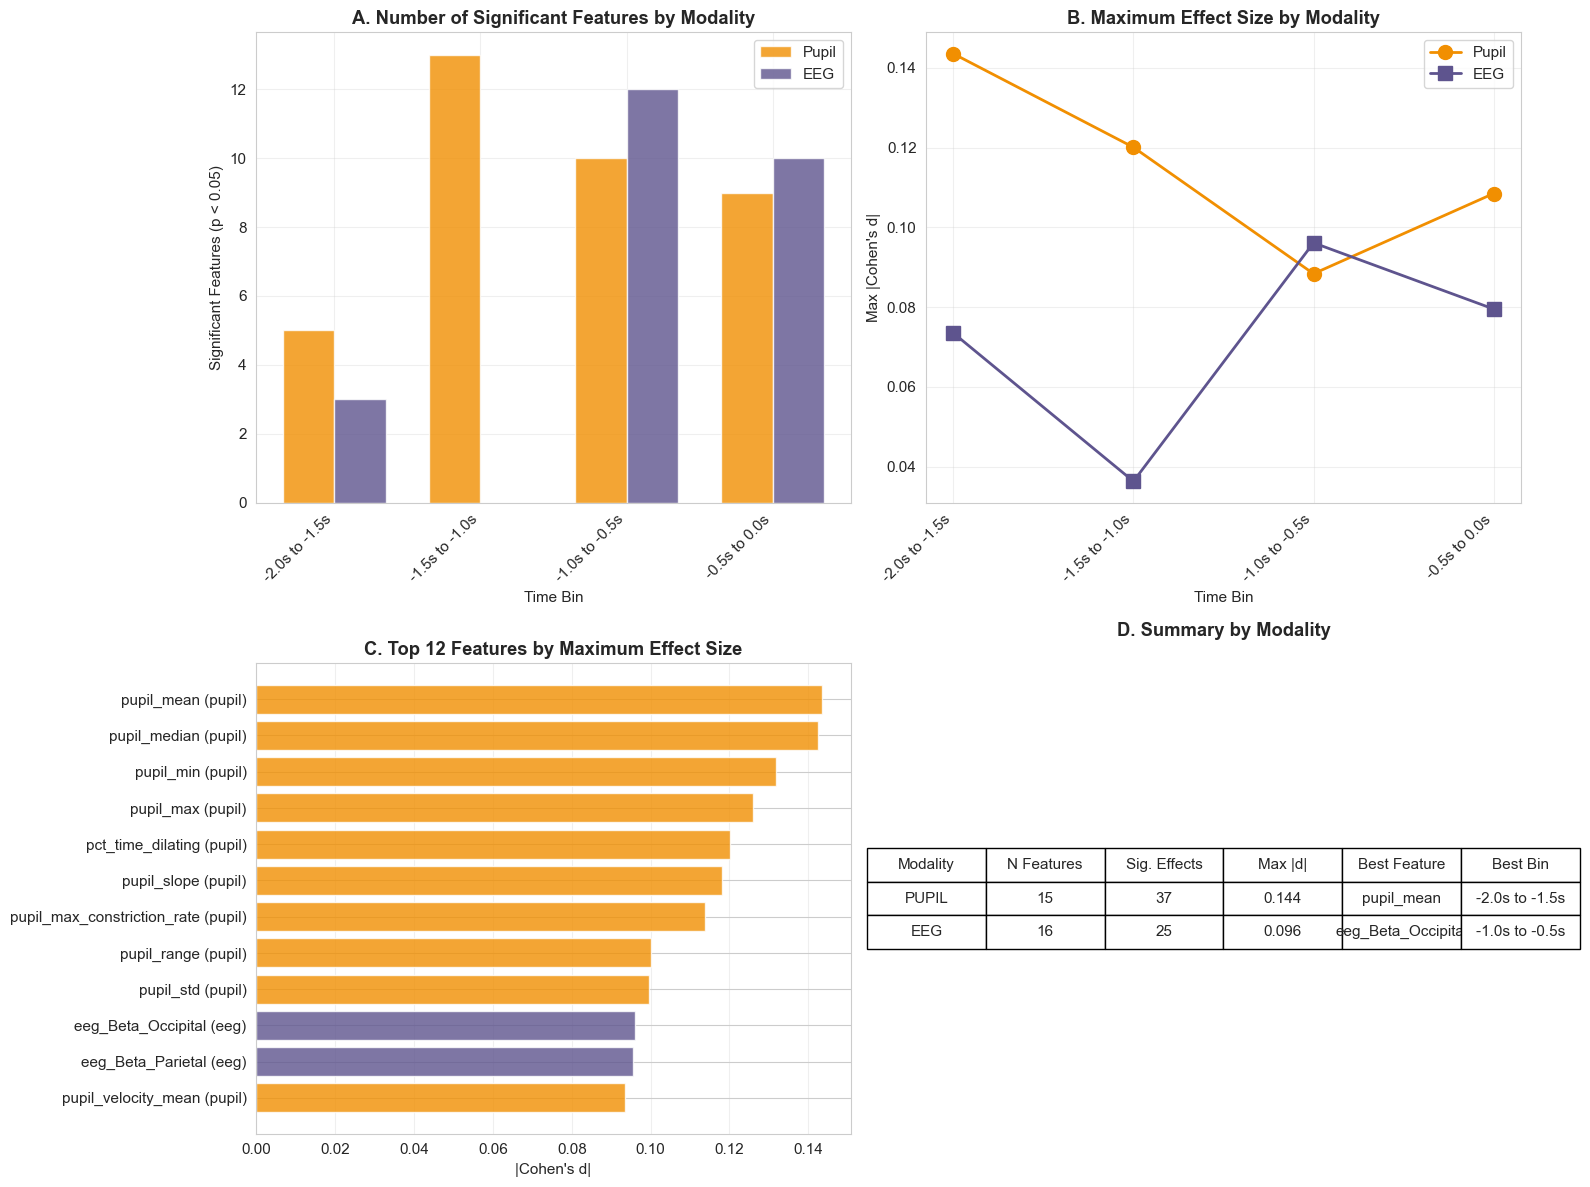

In [13]:
# Create unified visualization of all modalities
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Significant effects count by modality over time
ax1 = axes[0, 0]
sig_counts = temporal_df.groupby(['modality', 'bin_idx'])['significant'].sum().unstack(fill_value=0)

x = np.arange(len(TIME_BINS))
width = 0.35

pupil_sig = sig_counts.loc['pupil'].values if 'pupil' in sig_counts.index else np.zeros(len(TIME_BINS))
eeg_sig = sig_counts.loc['eeg'].values if 'eeg' in sig_counts.index else np.zeros(len(TIME_BINS))

ax1.bar(x - width/2, pupil_sig, width, label='Pupil', color='#F18F01', alpha=0.8)
ax1.bar(x + width/2, eeg_sig, width, label='EEG', color='#5E548E', alpha=0.8)

ax1.set_xlabel('Time Bin')
ax1.set_ylabel('Significant Features (p < 0.05)')
ax1.set_title('A. Number of Significant Features by Modality', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(BIN_LABELS, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# B. Max effect size by modality over time
ax2 = axes[0, 1]
max_effects = temporal_df.groupby(['modality', 'bin_idx'])['abs_cohens_d'].max().unstack(fill_value=0)

pupil_max = max_effects.loc['pupil'].values if 'pupil' in max_effects.index else np.zeros(len(TIME_BINS))
eeg_max = max_effects.loc['eeg'].values if 'eeg' in max_effects.index else np.zeros(len(TIME_BINS))

ax2.plot(x, pupil_max, marker='o', linewidth=2, markersize=10, label='Pupil', color='#F18F01')
ax2.plot(x, eeg_max, marker='s', linewidth=2, markersize=10, label='EEG', color='#5E548E')

ax2.set_xlabel('Time Bin')
ax2.set_ylabel("Max |Cohen's d|")
ax2.set_title('B. Maximum Effect Size by Modality', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(BIN_LABELS, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

# C. Top features by modality
ax3 = axes[1, 0]
top_features = temporal_df.groupby(['modality', 'feature'])['abs_cohens_d'].max().reset_index()
top_features = top_features.sort_values('abs_cohens_d', ascending=True).tail(12)

colors = ['#F18F01' if m == 'pupil' else '#5E548E' for m in top_features['modality']]
ax3.barh(range(len(top_features)), top_features['abs_cohens_d'], color=colors, alpha=0.8)
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels([f"{r['feature']} ({r['modality']})" for _, r in top_features.iterrows()])
ax3.set_xlabel("|Cohen's d|")
ax3.set_title('C. Top 12 Features by Maximum Effect Size', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# D. Summary statistics table
ax4 = axes[1, 1]
ax4.axis('off')

summary_data = []
for modality in ['pupil', 'eeg']:
    mod_df = temporal_df[temporal_df['modality'] == modality]
    if len(mod_df) > 0:
        strongest = mod_df.loc[mod_df['abs_cohens_d'].idxmax()]
        summary_data.append({
            'Modality': modality.upper(),
            'N Features': mod_df['feature'].nunique(),
            'Sig. Effects': mod_df['significant'].sum(),
            'Max |d|': f"{mod_df['abs_cohens_d'].max():.3f}",
            'Best Feature': strongest['feature'],
            'Best Bin': strongest['time_label']
        })

summary_table = pd.DataFrame(summary_data)
table = ax4.table(cellText=summary_table.values,
                  colLabels=summary_table.columns,
                  loc='center',
                  cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
ax4.set_title('D. Summary by Modality', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'unified_cross_modality_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Earliest Divergence Analysis

In [14]:
# Find earliest significant divergence for each feature
print("\n" + "="*90)
print("EARLIEST SIGNIFICANT DIVERGENCE BY MODALITY")
print("="*90)

for modality in ['pupil', 'eeg']:
    print(f"\n--- {modality.upper()} ---")
    mod_df = temporal_df[temporal_df['modality'] == modality]
    
    earliest_divergence = []
    for feature in mod_df['feature'].unique():
        feat_data = mod_df[(mod_df['feature'] == feature) & (mod_df['significant'] == True)]
        
        if len(feat_data) > 0:
            earliest = feat_data.sort_values('bin_idx').iloc[0]
            max_effect = mod_df[mod_df['feature'] == feature]['abs_cohens_d'].max()
            earliest_divergence.append({
                'feature': feature,
                'earliest_bin': earliest['time_label'],
                'earliest_d': earliest['cohens_d'],
                'max_d': max_effect
            })
    
    if len(earliest_divergence) > 0:
        earliest_df = pd.DataFrame(earliest_divergence).sort_values('earliest_bin')
        print(earliest_df.to_string(index=False))
    else:
        print("No significant effects found")


EARLIEST SIGNIFICANT DIVERGENCE BY MODALITY

--- PUPIL ---
                    feature   earliest_bin  earliest_d    max_d
              eye_asymmetry -1.0s to -0.5s   -0.051938 0.051938
                  pupil_std -1.5s to -1.0s    0.099477 0.099477
                pupil_range -1.5s to -1.0s    0.100190 0.100190
                pupil_slope -1.5s to -1.0s   -0.118061 0.118061
        pupil_velocity_mean -1.5s to -1.0s    0.093596 0.093596
         pupil_velocity_std -1.5s to -1.0s    0.081522 0.081522
    pupil_max_dilation_rate -1.5s to -1.0s   -0.060460 0.064911
pupil_max_constriction_rate -1.5s to -1.0s    0.113801 0.113801
    pupil_acceleration_mean -1.5s to -1.0s    0.057243 0.058456
          pct_time_dilating -1.5s to -1.0s   -0.120088 0.120088
                 pupil_mean -2.0s to -1.5s    0.143552 0.143552
               pupil_median -2.0s to -1.5s    0.142362 0.142362
                   pupil_cv -2.0s to -1.5s   -0.051552 0.051552
                  pupil_min -2.0s to -1.5s  

## 10. Save Results

In [15]:
# Save temporal results
temporal_df.to_csv(OUTPUT_DIR / 'multimodal_temporal_divergence.csv', index=False)

# Save summary
summary = {
    'analysis_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'window': f"{WINDOW_START}s to {WINDOW_END}s",
    'bin_size': f"{BIN_SIZE}s",
    'n_bins': len(TIME_BINS),
    'n_pupil_trials': len(df),
    'n_eeg_trials': df['has_eeg'].sum(),
    'n_subjects': df['subject_id'].nunique(),
    'temporal_results': temporal_df.to_dict('records')
}

with open(OUTPUT_DIR / 'multimodal_temporal_summary.pkl', 'wb') as f:
    pickle.dump(summary, f)

print("\n" + "="*80)
print("FILES SAVED")
print("="*80)
print(f"  - {OUTPUT_DIR / 'multimodal_temporal_divergence.csv'}")
print(f"  - {OUTPUT_DIR / 'multimodal_temporal_summary.pkl'}")
print(f"  - {OUTPUT_DIR / 'temporal_heatmaps_by_modality.png'}")
print(f"  - {OUTPUT_DIR / 'cross_modality_effect_comparison.png'}")
print(f"  - {OUTPUT_DIR / 'eeg_band_temporal_evolution.png'}")
print(f"  - {OUTPUT_DIR / 'eeg_region_temporal_evolution.png'}")
print(f"  - {OUTPUT_DIR / 'unified_cross_modality_summary.png'}")


FILES SAVED
  - ../../data/results/main/statistical_analyses/multimodal_temporal/multimodal_temporal_divergence.csv
  - ../../data/results/main/statistical_analyses/multimodal_temporal/multimodal_temporal_summary.pkl
  - ../../data/results/main/statistical_analyses/multimodal_temporal/temporal_heatmaps_by_modality.png
  - ../../data/results/main/statistical_analyses/multimodal_temporal/cross_modality_effect_comparison.png
  - ../../data/results/main/statistical_analyses/multimodal_temporal/eeg_band_temporal_evolution.png
  - ../../data/results/main/statistical_analyses/multimodal_temporal/eeg_region_temporal_evolution.png
  - ../../data/results/main/statistical_analyses/multimodal_temporal/unified_cross_modality_summary.png


## 11. Key Findings Summary

In [16]:
print("\n" + "="*80)
print("MULTIMODAL TEMPORAL DIVERGENCE: KEY FINDINGS")
print("="*80)

# Pupil summary
pupil_results = temporal_df[temporal_df['modality'] == 'pupil']
if len(pupil_results) > 0:
    strongest_pupil = pupil_results.loc[pupil_results['abs_cohens_d'].idxmax()]
    print(f"\n1. PUPIL SIGNALS:")
    print(f"   - Features analyzed: {pupil_results['feature'].nunique()}")
    print(f"   - Significant effects: {pupil_results['significant'].sum()} / {len(pupil_results)}")
    print(f"   - Strongest effect: {strongest_pupil['feature']} at {strongest_pupil['time_label']}")
    print(f"     (d = {strongest_pupil['cohens_d']:.3f}, p = {strongest_pupil['p_value']:.2e})")

# EEG summary
eeg_results = temporal_df[temporal_df['modality'] == 'eeg']
if len(eeg_results) > 0:
    strongest_eeg = eeg_results.loc[eeg_results['abs_cohens_d'].idxmax()]
    print(f"\n2. EEG SIGNALS:")
    print(f"   - Features analyzed: {eeg_results['feature'].nunique()}")
    print(f"   - Significant effects: {eeg_results['significant'].sum()} / {len(eeg_results)}")
    print(f"   - Strongest effect: {strongest_eeg['feature']} at {strongest_eeg['time_label']}")
    print(f"     (d = {strongest_eeg['cohens_d']:.3f}, p = {strongest_eeg['p_value']:.2e})")
    
    # Band analysis
    eeg_results_copy = eeg_results.copy()
    eeg_results_copy['band'] = eeg_results_copy['feature'].apply(lambda x: x.split('_')[1])
    band_summary = eeg_results_copy.groupby('band')['abs_cohens_d'].mean().sort_values(ascending=False)
    print(f"\n   - Band effects (avg |d|): {dict(band_summary.round(3))}")
else:
    print(f"\n2. EEG SIGNALS: No data available")

# Cross-modality comparison
print(f"\n3. CROSS-MODALITY COMPARISON:")
pupil_max = pupil_results['abs_cohens_d'].max() if len(pupil_results) > 0 else 0
eeg_max = eeg_results['abs_cohens_d'].max() if len(eeg_results) > 0 else 0
print(f"   - Max pupil effect: |d| = {pupil_max:.3f}")
print(f"   - Max EEG effect: |d| = {eeg_max:.3f}")
if pupil_max > eeg_max:
    print(f"   - Pupil shows stronger decision-related signals")
else:
    print(f"   - EEG shows stronger decision-related signals")

print(f"\n" + "="*80)
print(f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"="*80)


MULTIMODAL TEMPORAL DIVERGENCE: KEY FINDINGS

1. PUPIL SIGNALS:
   - Features analyzed: 15
   - Significant effects: 37 / 60
   - Strongest effect: pupil_mean at -2.0s to -1.5s
     (d = 0.144, p = 3.61e-12)

2. EEG SIGNALS:
   - Features analyzed: 16
   - Significant effects: 25 / 64
   - Strongest effect: eeg_Beta_Occipital at -1.0s to -0.5s
     (d = -0.096, p = 2.70e-05)

   - Band effects (avg |d|): {'Theta': np.float64(0.054), 'Beta': np.float64(0.043), 'Alpha': np.float64(0.038), 'Delta': np.float64(0.0)}

3. CROSS-MODALITY COMPARISON:
   - Max pupil effect: |d| = 0.144
   - Max EEG effect: |d| = 0.096
   - Pupil shows stronger decision-related signals

Analysis completed: 2026-03-29 20:09:09
